In [3]:
import numpy as np
from sklearn.datasets import make_classification

In [9]:
X,y = make_classification(n_samples=100, n_features = 2, n_informative=1, n_redundant=0,
                          n_classes = 2, n_clusters_per_class=1, random_state =41, hypercube=False, class_sep = 20)

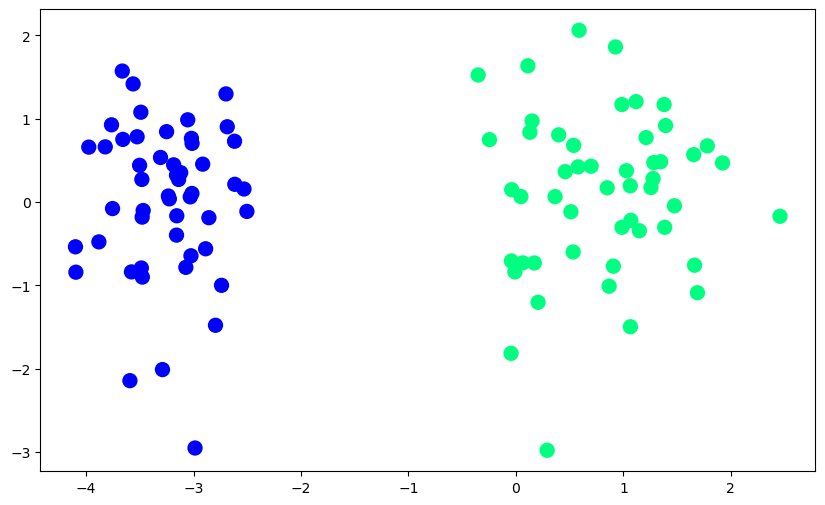

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(
    X[:,0],      # x coordinates → Feature 0
    X[:,1],      # y coordinates → Feature 1
    c=y,         # color → class label
    cmap='winter', # color scheme
    s=100        # point size
)

# Perceptron Weight Update — Worked Example

Walking through this line from the Perceptron code:

```
weights = weights + lr * (y - y_hat) * X
```

which corresponds to:

$$w_{new} = w_{old} + lr(y - \hat{y})X$$

---

## Example 1: Correct Prediction (No Update)

### Setup

$$X = [1, 2, 3]$$

The first `1` is the intercept term, so: $X = [1, x_1, x_2] = [1, 2, 3]$

Current weights:
$$w = [1, 1, 1]$$

Learning rate:
$$lr = 0.1$$

Actual class:
$$y = 1$$

### Step 1: Calculate Prediction

Dot product:
$$X \cdot w = (1)(1) + (2)(1) + (3)(1) = 6$$

Step function rule: $z > 0 \Rightarrow \hat{y} = 1$

So:
$$\hat{y} = 1$$

**The model was correct.**

### Step 2: Apply the Update

Substitute into the update rule:
$$w_{new} = [1,1,1] + 0.1(1-1)[1,2,3]$$

First:
$$1 - 1 = 0$$

Therefore:
$$w_{new} = [1,1,1] + 0[1,2,3] = [1,1,1]$$

**Nothing changes** — the Perceptron classified the point correctly.

---

## Example 2: Incorrect Prediction (Update Happens)

This is where the interesting part begins.

### Setup

$$X = [1, -2, -3]$$

Actual class:
$$y = 1$$

Current weights:
$$w = [1, 1, 1]$$

Learning rate:
$$lr = 0.1$$

### Step 1: Calculate Prediction

Dot product:
$$X \cdot w = (1)(1) + (-2)(1) + (-3)(1) = 1 - 2 - 3 = -4$$

Since $-4 < 0$, the step function gives:
$$\hat{y} = 0$$

But the actual answer is:
$$y = 1$$

**The Perceptron made a mistake.**

### Step 2: Apply the Update 🔥

$$w_{new} = w_{old} + lr(y - \hat{y})X$$

Substitute:
$$w_{new} = [1,1,1] + 0.1(1-0)[1,-2,-3]$$

First:
$$1 - 0 = 1$$

Then:
$$0.1 \times 1 \times [1,-2,-3] = [0.1, -0.2, -0.3]$$

Therefore:
$$w_{new} = [1,1,1] + [0.1,-0.2,-0.3] = [1.1, 0.8, 0.7]$$

---

## What Actually Happened?

The weights changed from:
$$[1,1,1] \rightarrow [1.1, 0.8, 0.7]$$

**Why?**

Because the Perceptron got:
$$actual = 1, \quad prediction = 0$$

So mathematically, it said:

> "I predicted too low. Adjust my weights in the direction of this example."

That is exactly what this term does:

$$(y - \hat{y})X$$

In [20]:
class Perceptron:
    def fit(self, X,y):
        # Add a column of ones for the intercept
        # X = [1, x₁, x₂]
        X= np.insert(X, 0, 1, axis =1)

        # Initialize weights
        # w = [b, w₁, w₂]
        weights = np.ones(X.shape[1])

        # The learning rate
        lr = 0.1

        for i in range(1000):
            # Randomly selecting one value from j = {0,1,2,3, ....,99}
            j = np.random.randint(0,100)

            # Calculate the y_hat = step(z) where z = X[j] · w - i.e b + w₁x₁ + w₂x₂
            y_hat = step(np.dot(X[j],weights))

            # Perceptron weight update:
            # w_new = w_old + η(y - ŷ)x
            weights = weights + lr * (y[j] - y_hat) * X[j]

        # Return:
        # weights[0] → intercept/bias (b)
        # weights[1:] → feature weights [w₁, w₂]
        self.intercept_ = weights[0]
        self.coef_ = weights[1:]

In [21]:
def step(z):
    return 1 if z > 0 else 0

In [22]:
model = Perceptron()
model.fit(X,y)

In [23]:
print(model.intercept_)
print(model.coef_)

1.2000000000000002
[1.0580085  0.40381514]


### converting the equation to the normal form for matplotlib to plot

In [24]:
# m = -w1/w2
m = -(model.coef_[0]/model.coef_[1])
print('Slope :', m)

#b = -(intercept/w2)
b = -(model.intercept_/model.coef_[1])
print("Intercept :", b)

Slope : -2.6200317952788446
Intercept : -2.9716568071029252


In [25]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

(-3.0, 2.0)

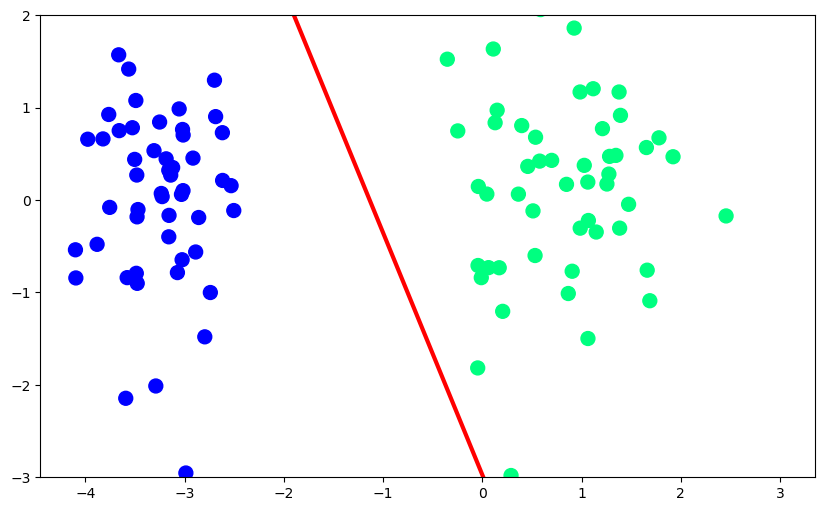

In [31]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input, color='red', linewidth=3 )
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

### Now, implementing the same using Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression()
lgr.fit(X,y)


LogisticRegression()

In [50]:
print(lgr.coef_)
print(lgr.intercept_)

[[2.36679363 0.02300492]]
[3.13571596]


In [38]:
m1 = -(lgr.coef_[0][0]/lgr.coef_[0][1])
b1 = -(lgr.intercept_/lgr.coef_[0][1])

In [39]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

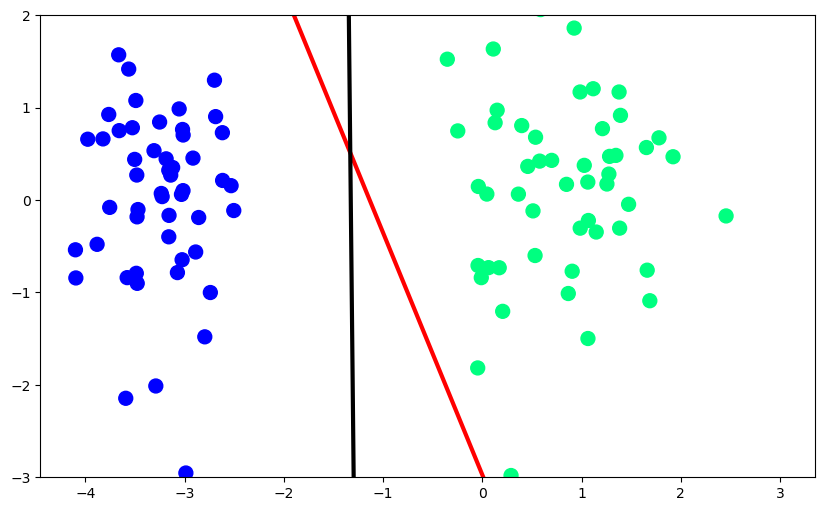

In [43]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [44]:
class SigmoidFunction:
    def fit(self,X,y):
        
        X = np.insert(X,0,1,axis=1)
        weights = np.ones(X.shape[1])
        lr = 0.1

        for i in range(1000):
            j = np.random.randint(0,100)
            y_hat = sigmoid(np.dot(X[j],weights))
            weights = weights + lr*(y[j]-y_hat)*X[j]

        self.intercept_ = weights[0]
        self.coef_ = weights[1:]
        

In [45]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [46]:
mdl = SigmoidFunction()
mdl.fit(X,y)

In [47]:
print(mdl.intercept_)
print(mdl.coef_)

2.88178134463158
[2.86396047 0.09350404]


In [51]:
# m = -w1/w2
m2 = -(mdl.coef_[0]/mdl.coef_[1])
print('Slope :', m)

#b = -(intercept/w2)
b2 = -(mdl.intercept_/mdl.coef_[1])
print("Intercept :", b)

Slope : -102.88205179540327
Intercept : [-136.30630349]


In [52]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

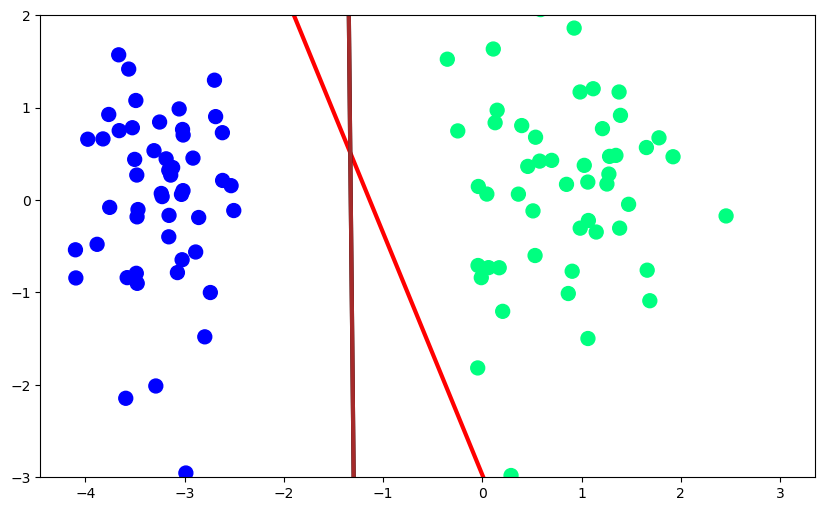

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)